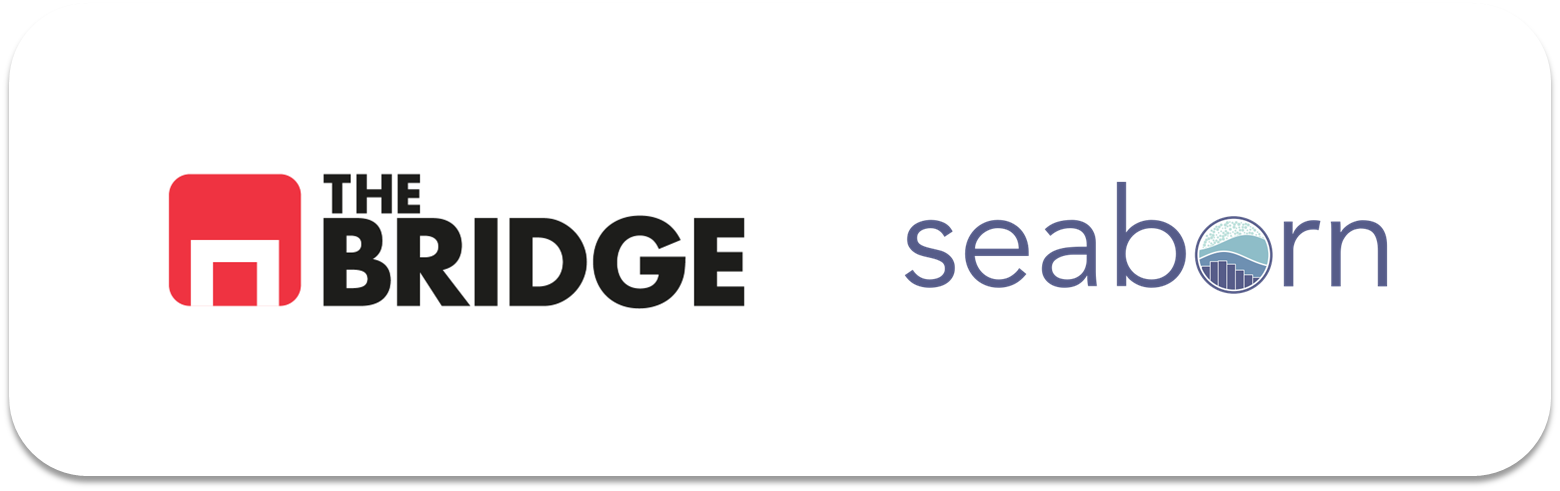

## PRACTICA OBLIGATORIA: **Visualización Avanzada y Presentación**

* La práctica obligatoria de esta unidad se divide en dos partes, una dedicada a visualización y construcción de funciones, y la otra a hacer una presentación de resultados. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [11]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## #1: Visualización

### #1.1

Carga el dataset de las ciudades de California que está en la ruta "./data/california_cities.csv". Muestra su contenido, deshazte de las filas con nulos.

In [12]:
df_ciudades = pd.read_csv("./data/california_cities.csv")
df_ciudades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          482 non-null    int64  
 1   city                482 non-null    object 
 2   latd                482 non-null    float64
 3   longd               482 non-null    float64
 4   elevation_m         434 non-null    float64
 5   elevation_ft        470 non-null    float64
 6   population_total    482 non-null    int64  
 7   area_total_sq_mi    480 non-null    float64
 8   area_land_sq_mi     482 non-null    float64
 9   area_water_sq_mi    481 non-null    float64
 10  area_total_km2      477 non-null    float64
 11  area_land_km2       478 non-null    float64
 12  area_water_km2      478 non-null    float64
 13  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 52.8+ KB


In [13]:
df_ciudades.dropna(inplace=True)

In [14]:
df_ciudades.info()

<class 'pandas.core.frame.DataFrame'>
Index: 427 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          427 non-null    int64  
 1   city                427 non-null    object 
 2   latd                427 non-null    float64
 3   longd               427 non-null    float64
 4   elevation_m         427 non-null    float64
 5   elevation_ft        427 non-null    float64
 6   population_total    427 non-null    int64  
 7   area_total_sq_mi    427 non-null    float64
 8   area_land_sq_mi     427 non-null    float64
 9   area_water_sq_mi    427 non-null    float64
 10  area_total_km2      427 non-null    float64
 11  area_land_km2       427 non-null    float64
 12  area_water_km2      427 non-null    float64
 13  area_water_percent  427 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 50.0+ KB


### #1.2

Crea una función similar a la que se pide en el ejercicio 6 de la segunda tanda de ejercicios del workout. Es decir, una función para pintar diagramas de dispersion que tenga seis argumentos, pero ojo al cambio en el quinto:
1. Un dataframe
2. Una columna numérica del dataframe
3. Una columna numérica del dataframe diferente a la anterior.
4. Un columna categórica (Opcional, valor por defecto None)
5. Un valor para el tamaño de los puntos o una cadena, pero que puede ser una cadena de caracteres, en cuyo caso se debe interpretar como una de las columnas del dataframe cuyos valores deben controlar el tamaño
6. Un sexto argumento "escala", que permita manipular la escala del tamaño en el caso de que el quinto argumento sea una cadena. Este argumento multiplicará a los valores de la columna indicada en el parámetro anterior (así si quiero dividir por 10000, este sexto argumento tendrá que valer 1/10000)

La función debe pintar el diagrama de dispersión de la columna numérica 1, en el eje X, frente a la columna numérica 2, en el eje Y, usando un código de colores en función de la columna categórica y con el tamaño de los puntos según el argumento correspondiente. 

Si no se diera una columna categórica como argumento, el color no debe pasarse como parámetro a la función de Seaborn o Matplotlib que uses.

EXTRA: Añade un argumento que controle si la función pinta una leyenda para colores y tamaños o un colorbar y una leyenda para los tamaños. NO TE PREOCUPES POR EL FORMATO DE LA LEYENDA (lo veremos en la sesión en vivo)

In [66]:
def dispersion(df, numerica1, numerica2, categorica = None, tamaño=20, escala = 1, leyenda = True, colorbar=True):
    plt.figure(figsize=(14,8))
    if type(tamaño)== str:
        tamañofinal = df[tamaño]*escala
        sns.scatterplot(x= numerica1,
            y= numerica2,
            data = df,
            hue= categorica,
            size=tamañofinal,
            sizes =(1,300),
            legend = leyenda);

    else:
         sns.scatterplot(x= numerica1,
                y= numerica2,
                data = df,
                hue= categorica,
                size=tamaño,
                sizes =(1,300),
                legend = leyenda)



### #1.3

Pinta el diagrama de dispersión de longitud y latitud (longitud en las x, latitud en las y) de las ciudades, usando el tamaño de las ciudades para el tamaño de los puntos y los colores para mostrar la población. Previamente crea una columna nueva "log_poblacion" y asignale el log decimal de la poblacion (np.log10() y como argumento los valores de la columna "population_total"). Usa "log_poblacion" para el color.

In [ ]:
df_ciudades ["log_poblacion"]=np.log10(df_ciudades["population_total"])



In [27]:
df_ciudades["area_total_km2"] = pd.to_numeric(df_ciudades["area_total_km2"], errors="coerce")


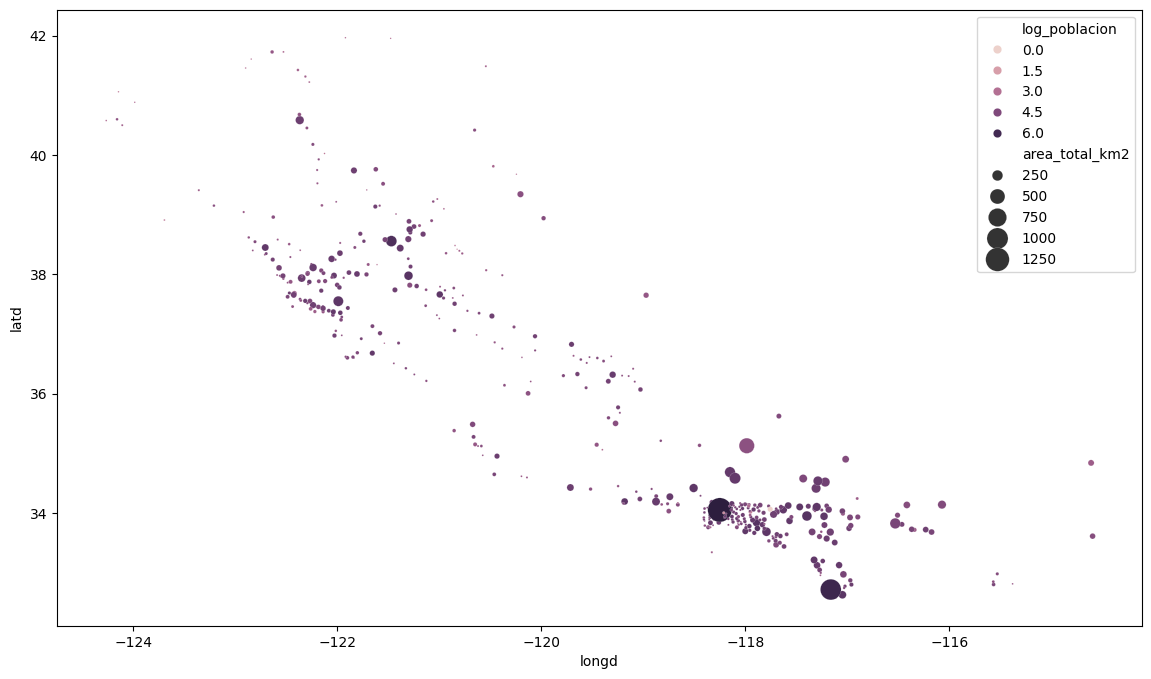

In [67]:
dispersion(df_ciudades, "longd","latd","log_poblacion","area_total_km2")

Un ejemplo de como podría salir para que lo tengas de referencia: (olvidate de la leyenda, auque si quieres como extra puedes intentar ver cómo crearla así)

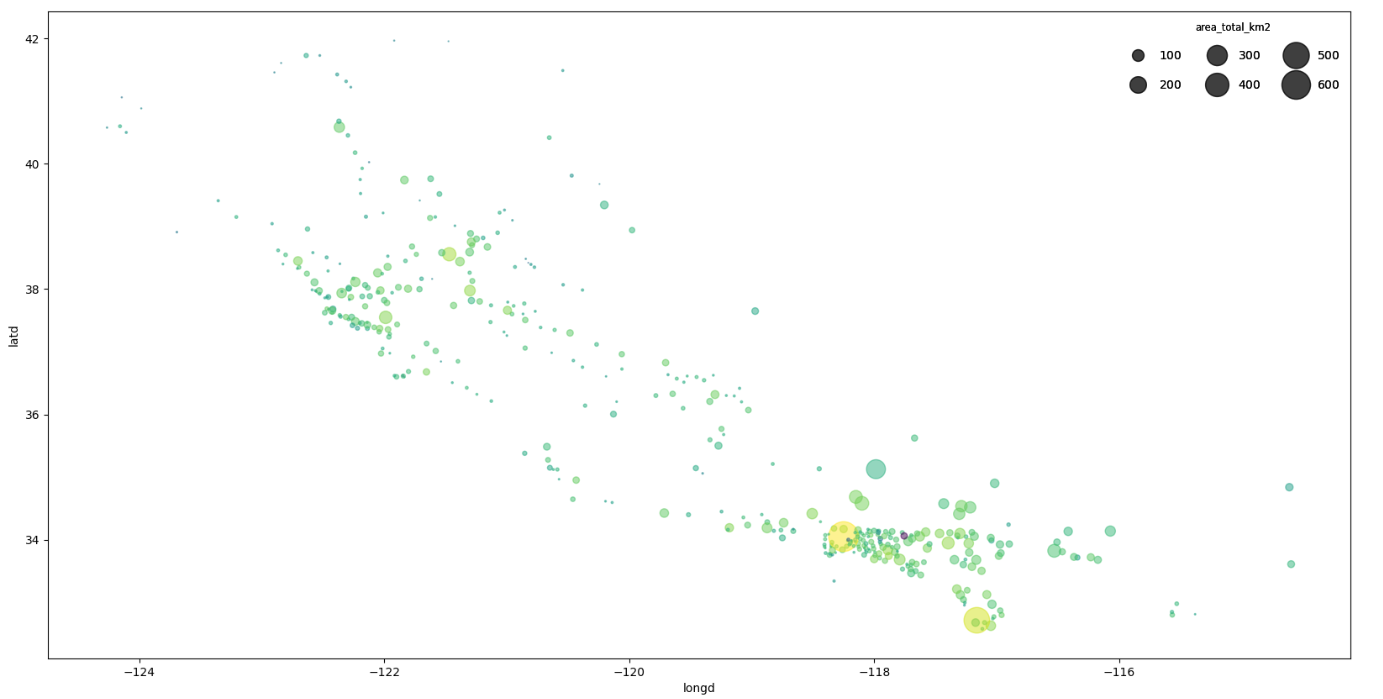

## #2: Presentación

En esta parte tendrás que hacer dos cosas:

#2.1 Crear una presentación sencilla sobre el Titanic de no más de 6 slides, sin incluir portada, con los siguientes mensajes y su apoyo en datos:  

1. El titanic fue un accidente con una tasa de mortalidad alta.  

2. Los datos apoyan que se dio el "Las mujeres y los niños primero", pero...  
3. ...la clase en la que viajases tuvo una influencia significativa y podría explicar...  
4. ...las diferencias entre tasas de supervivencia de mujeres y niños.    
5. Además, aunque el puerto de embarque parece tener influencia, se podría asumir que más bien fue la clase de pasaje que embarcó en cada uno de ellos.  

#2.2 Las gráficas a emplear en la presentación debes generarlas en un notebook.  

Tienes que entregar ambas cosas: presentación y notebook :)

In [95]:
df_titanic = pd.read_csv("./data/titanic.csv")
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


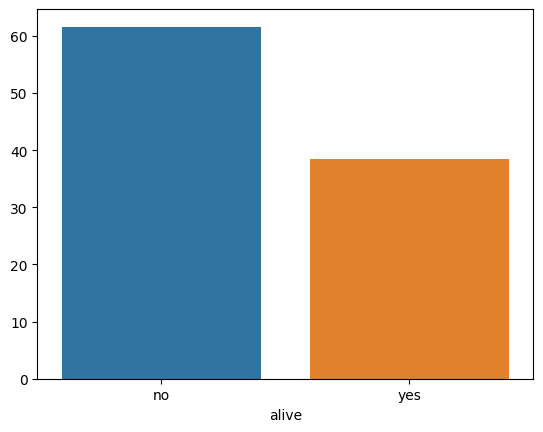

In [99]:
valores = df_titanic.alive.value_counts(normalize = True) * 100
bars = sns.barplot(x = valores.index, y = valores.values, hue = valores.index)


     who alive  count
0  child   yes     49
1  child    no     34
2    man    no    449
3    man   yes     88
4  woman   yes    205
5  woman    no     66
     who alive  proportion
0  child   yes    0.590361
1  child    no    0.409639
2    man    no    0.836127
3    man   yes    0.163873
4  woman   yes    0.756458
5  woman    no    0.243542


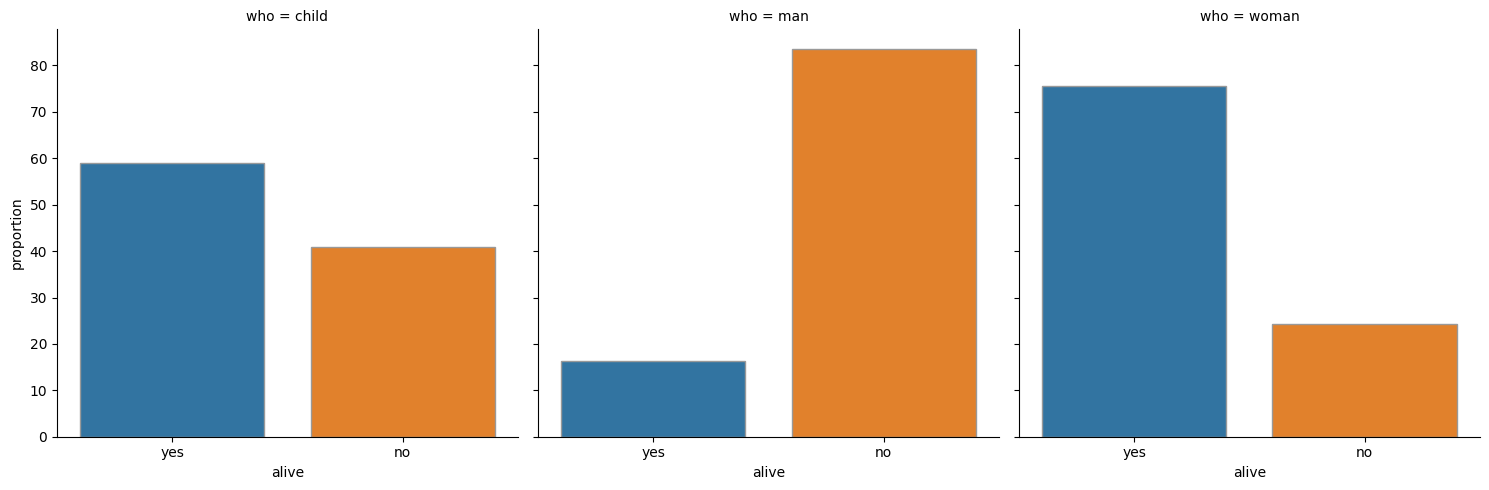

In [87]:
cat_colx ="alive"
cat_coly ="who"
frecuencias_absolutas = df_titanic.groupby(cat_coly, as_index=False)[cat_colx].value_counts()
frecuencias_relativas = df_titanic.groupby(cat_coly, as_index=False)[cat_colx].value_counts(normalize=True)
print(frecuencias_absolutas)
print(frecuencias_relativas)
frecuencias_relativas["proportion"] *= 100
sns.catplot(x="alive",
            y = "proportion",
            col="who",
            hue = "alive",
            kind="bar", # Ojo, cambio el tipo de gráfico (ahora no "cuento" filas)
            edgecolor=".6",
            data=frecuencias_relativas);

    class alive  count
0   First   yes    136
1   First    no     80
2  Second    no     97
3  Second   yes     87
4   Third    no    372
5   Third   yes    119
    class alive  proportion
0   First   yes    0.629630
1   First    no    0.370370
2  Second    no    0.527174
3  Second   yes    0.472826
4   Third    no    0.757637
5   Third   yes    0.242363


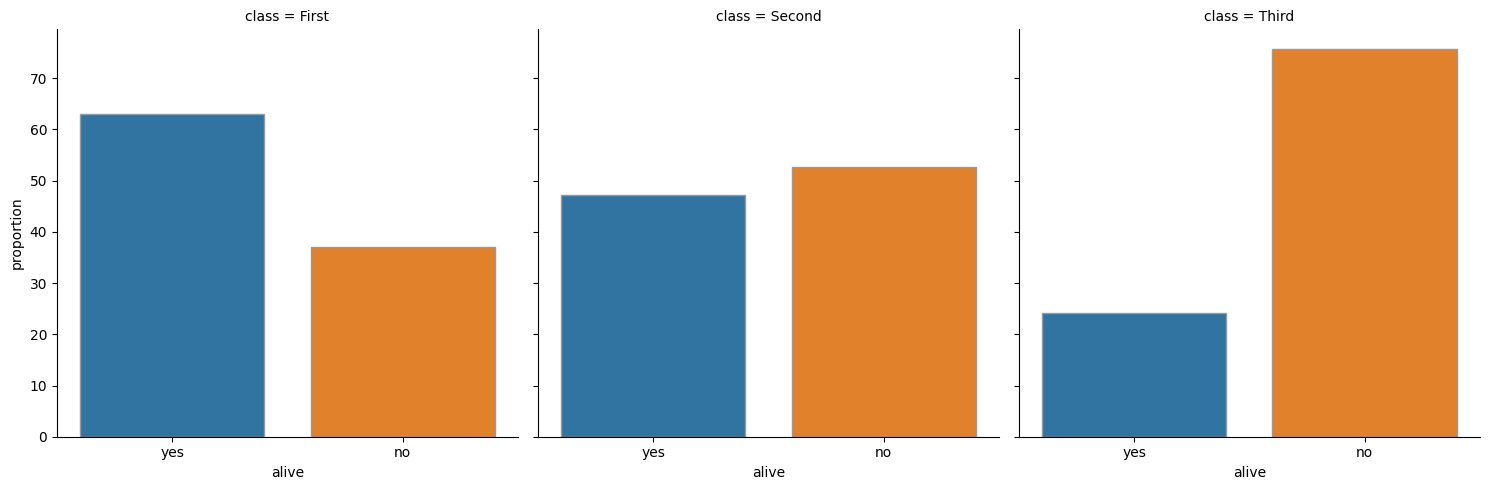

In [86]:
cat_colx ="alive"
cat_coly ="class"
frecuencias_absolutas = df_titanic.groupby(cat_coly, as_index=False)[cat_colx].value_counts()
frecuencias_relativas = df_titanic.groupby(cat_coly, as_index=False)[cat_colx].value_counts(normalize=True)
print(frecuencias_absolutas)
print(frecuencias_relativas)
frecuencias_relativas["proportion"] *= 100
sns.catplot(x="alive",
            y = "proportion",
            col="class",
            hue = "alive",
            kind="bar", # Ojo, cambio el tipo de gráfico (ahora no "cuento" filas)
            edgecolor=".6",
            data=frecuencias_relativas);

    class    who  count
0   First    man    119
1   First  woman     91
2   First  child      6
3  Second    man     99
4  Second  woman     66
5  Second  child     19
6   Third    man    319
7   Third  woman    114
8   Third  child     58
    class    who  proportion
0   First  woman    0.938144
1   First  child    0.061856
2  Second  woman    0.776471
3  Second  child    0.223529
4   Third  woman    0.662791
5   Third  child    0.337209


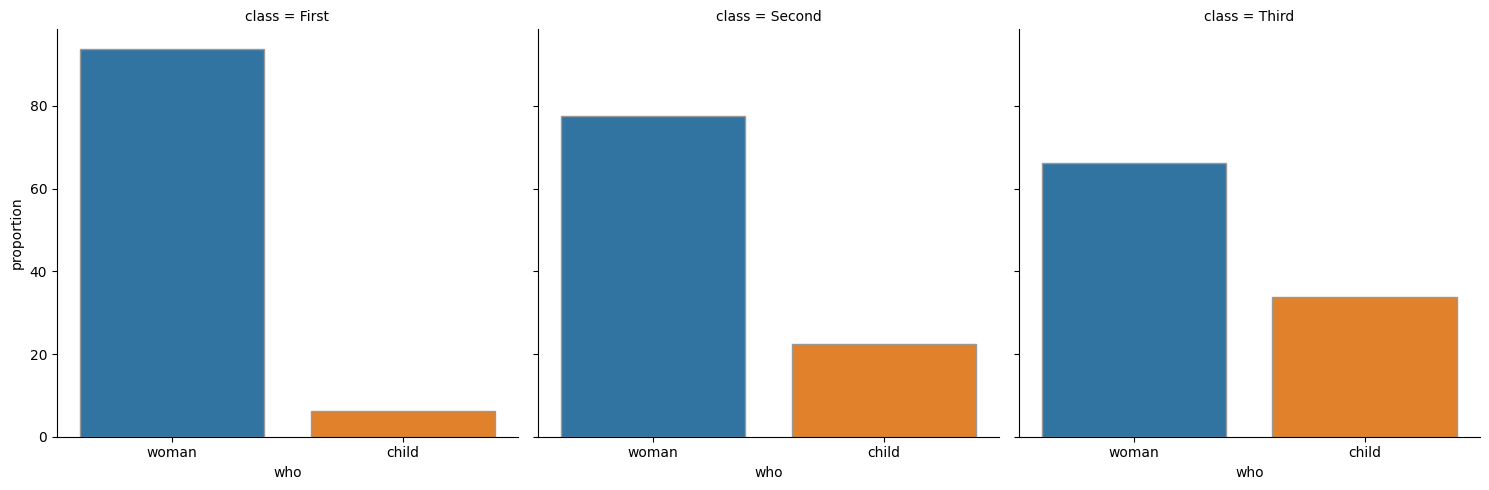

In [93]:
cat_colx ="who"
cat_coly ="class"
frecuencias_absolutas = df_titanic.groupby(cat_coly, as_index=False)[cat_colx].value_counts()
frecuencias_relativas = df_titanic[df_titanic["who"]!="man"].groupby(cat_coly, as_index=False)[[cat_colx]].value_counts(normalize=True)
print(frecuencias_absolutas)
print(frecuencias_relativas)
frecuencias_relativas["proportion"] *= 100
sns.catplot(x="who",
            y = "proportion",
            col="class",
            hue = "who",
            kind="bar", # Ojo, cambio el tipo de gráfico (ahora no "cuento" filas)
            edgecolor=".6",
            data=frecuencias_relativas);

   embark_town alive  count
0    Cherbourg   yes     93
1    Cherbourg    no     75
2   Queenstown    no     47
3   Queenstown   yes     30
4  Southampton    no    427
5  Southampton   yes    217
   embark_town alive  proportion
0    Cherbourg   yes    0.553571
1    Cherbourg    no    0.446429
2   Queenstown    no    0.610390
3   Queenstown   yes    0.389610
4  Southampton    no    0.663043
5  Southampton   yes    0.336957


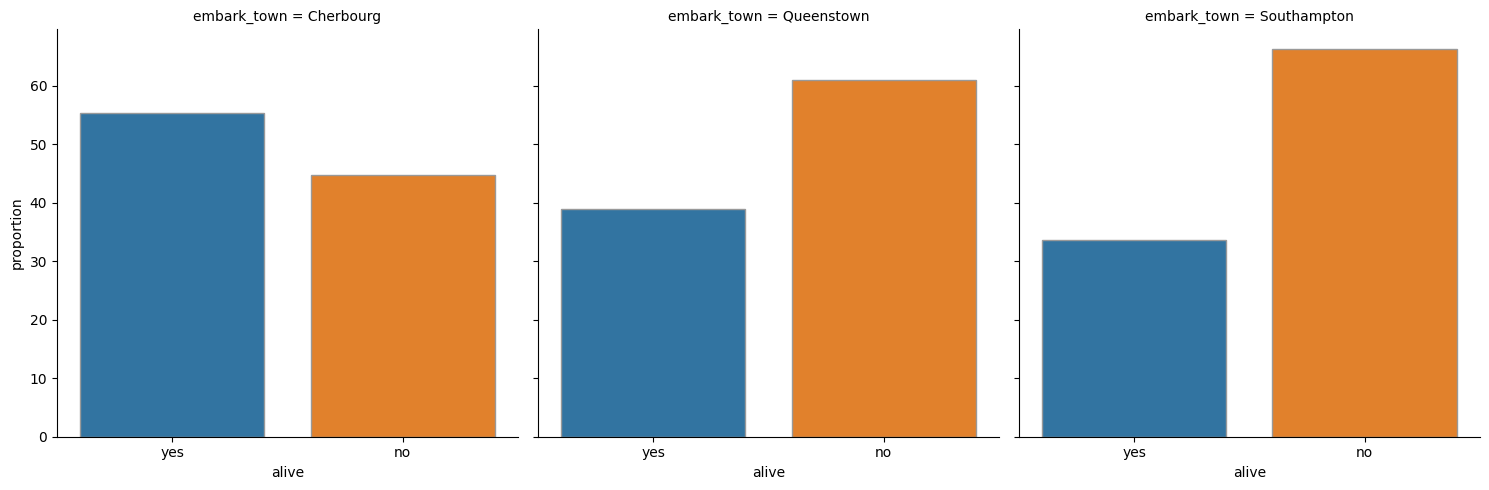

In [96]:
cat_colx ="alive"
cat_coly ="embark_town"
frecuencias_absolutas = df_titanic.groupby(cat_coly, as_index=False)[cat_colx].value_counts()
frecuencias_relativas = df_titanic.groupby(cat_coly, as_index=False)[cat_colx].value_counts(normalize=True)
print(frecuencias_absolutas)
print(frecuencias_relativas)
frecuencias_relativas["proportion"] *= 100
sns.catplot(x="alive",
            y = "proportion",
            col="embark_town",
            hue = "alive",
            kind="bar", # Ojo, cambio el tipo de gráfico (ahora no "cuento" filas)
            edgecolor=".6",
            data=frecuencias_relativas);

   embark_town   class  count
0    Cherbourg   First     85
1    Cherbourg   Third     66
2    Cherbourg  Second     17
3   Queenstown   Third     72
4   Queenstown  Second      3
5   Queenstown   First      2
6  Southampton   Third    353
7  Southampton  Second    164
8  Southampton   First    127
   embark_town   class  proportion
0    Cherbourg   First    0.505952
1    Cherbourg   Third    0.392857
2    Cherbourg  Second    0.101190
3   Queenstown   Third    0.935065
4   Queenstown  Second    0.038961
5   Queenstown   First    0.025974
6  Southampton   Third    0.548137
7  Southampton  Second    0.254658
8  Southampton   First    0.197205


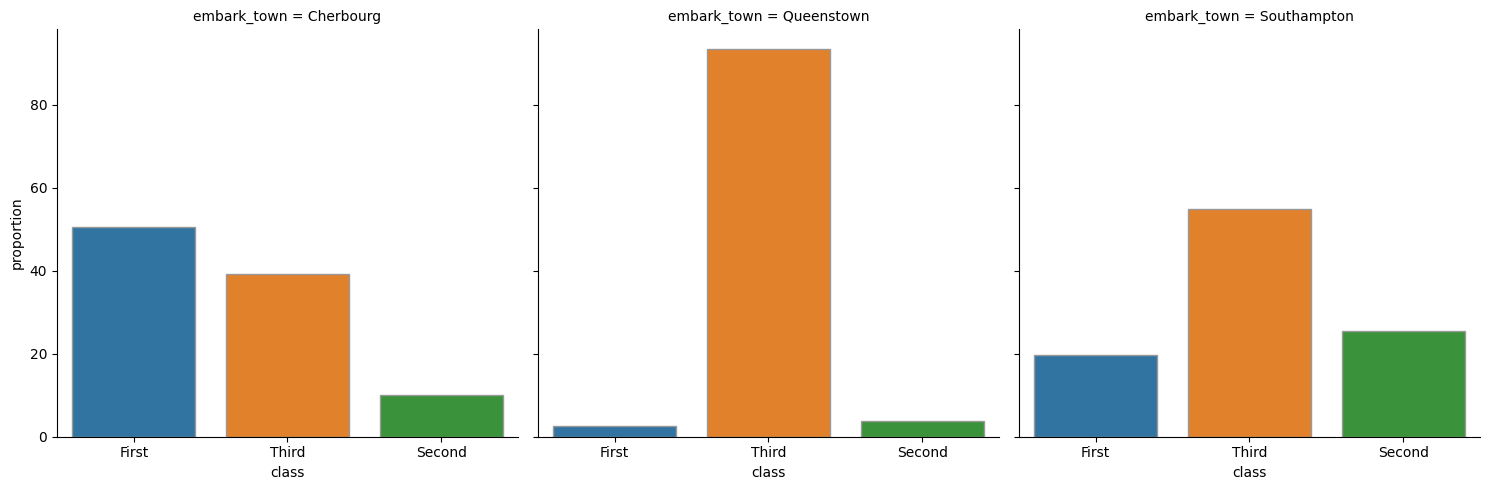

In [98]:
cat_colx ="class"
cat_coly ="embark_town"
frecuencias_absolutas = df_titanic.groupby(cat_coly, as_index=False)[cat_colx].value_counts()
frecuencias_relativas = df_titanic.groupby(cat_coly, as_index=False)[cat_colx].value_counts(normalize=True)
print(frecuencias_absolutas)
print(frecuencias_relativas)
frecuencias_relativas["proportion"] *= 100
sns.catplot(x="class",
            y = "proportion",
            col="embark_town",
            hue = "class",
            kind="bar", # Ojo, cambio el tipo de gráfico (ahora no "cuento" filas)
            edgecolor=".6",
            data=frecuencias_relativas);